In [1]:
import pickle
import pandas as pd
import numpy as np
from tqdm.auto import tqdm, trange
import re
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('sp.csv')

In [3]:
data.shape

(81191, 5)

In [4]:
data.head(5)

,Название,Артикул,Категория,Цена без карты,Цена с картой
0,Вентилятор BORGE Подкровельный Viotto черепаха...,17162001,Строительные материалы,1 514.15 ₽,1 438.44 ₽
1,Лента вентиляционная ПВХ 10х500 см,18824701,Строительные материалы,554.63 ₽,526.90 ₽
2,Проходка BORGE Кровельная D6-50мм прямая №1,17162301,Строительные материалы,329.33 ₽,312.86 ₽
3,Вентиляционная труба ОНДУВИЛЛА,19190801,Строительные материалы,4 099.00 ₽,3 894.05 ₽
4,Выход вентиляционный ТЕХНОНИКОЛЬ Изолированный...,19190601,Строительные материалы,3 799.00 ₽,3 609.05 ₽


In [5]:
print(data['Категория'].unique(), len(data['Категория'].unique()))

['Строительные материалы' 'Инструменты и крепёж' 'Двери, окна, замки'
 'Обои' 'Напольные покрытия' 'Потолочные и стеновые покрытия'
 'Керамическая плитка' 'Краски, герметики, пропитки'
 'Инженерная электрика, лампы' 'Сауны и бани'
 'Интерьер, текстиль, камины, оформление окон, картины'
 'Хранение и порядок' 'Товары для дома, подарки, бытовая химия'
 'Кухни, мойки, смесители, бытовая техника'
 'Вентиляция, климатическое оборудование' 'Освещение'
 'Отопление, водоснабжение, канализация'
 'Сантехника, мебель для ванной комнаты' 'Туризм и отдых' 'Автотовары'
 'Сад и огород'] 21


In [6]:
print(data['Название'].unique(), len(data['Название'].unique()))

['Вентилятор BORGE Подкровельный Viotto черепаха для МЧ'
 'Лента вентиляционная ПВХ 10х500 см'
 'Проходка BORGE Кровельная D6-50мм прямая №1' ...
 'Сетка СЛАВРОС Универсал L' 'Решётка заборная FULEREN 1х50м'
 'Сетка СЛАВРОС Универсал M'] 80433


# Выборка данных

In [7]:
topics = ['Строительные материалы','Инструменты и крепёж', 'Двери, окна, замки',
 'Обои', 'Напольные покрытия', 'Потолочные и стеновые покрытия',
 'Керамическая плитка', 'Краски, герметики, пропитки',
 'Инженерная электрика, лампы', 'Сауны и бани',
 'Интерьер, текстиль, камины, оформление окон, картины',
 'Хранение и порядок', 'Товары для дома, подарки, бытовая химия',
 'Кухни, мойки, смесители, бытовая техника',
 'Вентиляция, климатическое оборудование', 'Освещение',
 'Отопление, водоснабжение, канализация',
 'Сантехника, мебель для ванной комнаты', 'Туризм и отдых', 'Автотовары',
 'Сад и огород']
pack_in_cat = 3000

In [8]:
df_res = pd.DataFrame()

for topic in tqdm(topics):
    df_topic = data[data['Категория'] == topic][:pack_in_cat]
    df_res = df_res.append(df_topic)

In [9]:
df_res.head(5)

,Название,Артикул,Категория,Цена без карты,Цена с картой
0,Вентилятор BORGE Подкровельный Viotto черепаха...,17162001,Строительные материалы,1 514.15 ₽,1 438.44 ₽
1,Лента вентиляционная ПВХ 10х500 см,18824701,Строительные материалы,554.63 ₽,526.90 ₽
2,Проходка BORGE Кровельная D6-50мм прямая №1,17162301,Строительные материалы,329.33 ₽,312.86 ₽
3,Вентиляционная труба ОНДУВИЛЛА,19190801,Строительные материалы,4 099.00 ₽,3 894.05 ₽
4,Выход вентиляционный ТЕХНОНИКОЛЬ Изолированный...,19190601,Строительные материалы,3 799.00 ₽,3 609.05 ₽



# Предобработка

In [10]:
import string
def remove_punctuation(text):
    return "".join([ch if ch not in string.punctuation else ' ' for ch in text])

def remove_numbers(text):
    return ''.join([i if not i.isdigit() else ' ' for i in text])

import re
def remove_multiple_spaces(text):
	return re.sub(r'\s+', ' ', text, flags=re.I)

import nltk
nltk.download('stopwords')
from nltk.stem import *
from nltk.corpus import stopwords
from pymystem3 import Mystem
from string import punctuation
mystem = Mystem() 

russian_stopwords = stopwords.words("russian")
russian_stopwords.extend(['…', '«', '»', '...'])
def lemmatize_text(text):
    tokens = mystem.lemmatize(text.lower())
    tokens = [token for token in tokens if token not in russian_stopwords and token != " "]
    text = " ".join(tokens)
    return text

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/mugichu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<ipython-input-11-4e4adeaa338a>:26: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(1, 2, 1)


<AxesSubplot:>

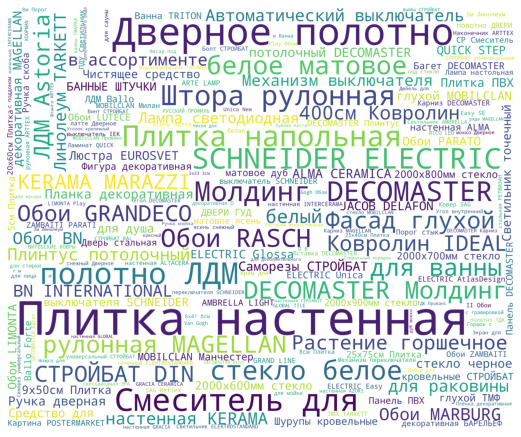

In [11]:
def str_corpus(corpus):
    str_corpus = ''
    for i in corpus:
        str_corpus += ' ' + i
    str_corpus = str_corpus.strip()
    return str_corpus
# Получение списка всех слов в корпусе
def get_corpus(data):
    corpus = []
    for phrase in data:
        for word in phrase.split():
            corpus.append(word)
    return corpus
# Получение облака слов
def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',width=3000,height=2500,max_words=200,random_state=42).generate(str_corpus(corpus))
    return wordCloud

corpus = get_corpus(df_res['Название'].values)
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

In [12]:
prep_text = [remove_multiple_spaces(remove_numbers(remove_punctuation(text.lower()))) for text in tqdm(df_res['Название'])]


In [13]:
len(prep_text)
prep_text[1]

'лента вентиляционная пвх х см'

In [14]:
df_res['text_prep'] = prep_text
df_res.head(1)

,Название,Артикул,Категория,Цена без карты,Цена с картой,text_prep
0,Вентилятор BORGE Подкровельный Viotto черепаха...,17162001,Строительные материалы,1 514.15 ₽,1 438.44 ₽,вентилятор borge подкровельный viotto черепаха...


In [15]:
from nltk.stem.snowball import SnowballStemmer 
stemmer = SnowballStemmer("russian")

In [16]:
russian_stopwords = stopwords.words("russian")
russian_stopwords.extend(['…', '«', '»', '...', 'т.д.', 'т', 'д','Главная','Каталог'])

In [17]:
import nltk
nltk.download('punkt')
from nltk import word_tokenize
text = df_res['text_prep'][0]
word_tokenize(text)

[nltk_data] Downloading package punkt to /home/mugichu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


['вентилятор', 'borge', 'подкровельный', 'viotto', 'черепаха', 'для', 'мч']

In [18]:
from nltk import word_tokenize

stemmed_texts_list = []
for text in tqdm(df_res['text_prep']):
    tokens = word_tokenize(text)    
    stemmed_tokens = [stemmer.stem(token) for token in tokens if token not in russian_stopwords]
    text = " ".join(stemmed_tokens)
    stemmed_texts_list.append(text)

df_res['text_stem'] = stemmed_texts_list

In [19]:
def remove_stop_words(text):
    tokens = word_tokenize(text) 
    tokens = [token for token in tokens if token not in russian_stopwords and token != ' ']
    return " ".join(tokens)

In [20]:
from nltk import word_tokenize

sw_texts_list = []
for text in tqdm(df_res['text_prep']):
    tokens = word_tokenize(text)    
    tokens = [token for token in tokens if token not in russian_stopwords and token != ' ']
    text = " ".join(tokens)
    sw_texts_list.append(text)

df_res['text_sw'] = sw_texts_list

In [21]:
df_res['text_sw'][0]

'вентилятор borge подкровельный viotto черепаха мч'

In [22]:
df_res.to_csv('sp_stemmed.csv')

In [23]:
df_res['text_stem'][0]

'вентилятор borge подкровельн viotto черепах мч'

# Лемматизация

In [24]:
lemm_texts_list = []
for text in tqdm(df_res['text_sw']):
    #print(text)
    try:
        text_lem = mystem.lemmatize(text)
        tokens = [token for token in text_lem if token != ' ' and token not in russian_stopwords]
        text = " ".join(tokens)
        lemm_texts_list.append(text)
    except Exception as e:
        print(e)
    
df_res['text_lemm'] = lemm_texts_list

In [25]:
def lemmatize_text(text):
    text_lem = mystem.lemmatize(text)
    tokens = [token for token in text_lem if token != ' ']
    return " ".join(tokens)

In [26]:
df_res.to_csv('lemm.csv')

In [27]:
df_res = pd.read_csv('lemm.csv', encoding = 'utf-8')

In [28]:
df_res.head()

,Unnamed: 0,Название,Артикул,Категория,Цена без карты,Цена с картой,text_prep,text_stem,text_sw,text_lemm
0,0,Вентилятор BORGE Подкровельный Viotto черепаха...,17162001,Строительные материалы,1 514.15 ₽,1 438.44 ₽,вентилятор borge подкровельный viotto черепаха...,вентилятор borge подкровельн viotto черепах мч,вентилятор borge подкровельный viotto черепаха мч,вентилятор borge подкровельный viotto черепаха...
1,1,Лента вентиляционная ПВХ 10х500 см,18824701,Строительные материалы,554.63 ₽,526.90 ₽,лента вентиляционная пвх х см,лент вентиляцион пвх х см,лента вентиляционная пвх х см,лента вентиляционный пвх х см \n
2,2,Проходка BORGE Кровельная D6-50мм прямая №1,17162301,Строительные материалы,329.33 ₽,312.86 ₽,проходка borge кровельная d мм прямая №,проходк borge кровельн d мм прям №,проходка borge кровельная d мм прямая №,проходка borge кровельный d мм прямой № \n
3,3,Вентиляционная труба ОНДУВИЛЛА,19190801,Строительные материалы,4 099.00 ₽,3 894.05 ₽,вентиляционная труба ондувилла,вентиляцион труб ондувилл,вентиляционная труба ондувилла,вентиляционный труба ондувилла \n
4,4,Выход вентиляционный ТЕХНОНИКОЛЬ Изолированный...,19190601,Строительные материалы,3 799.00 ₽,3 609.05 ₽,выход вентиляционный технониколь изолированный...,выход вентиляцион техноникол изолирова d мм,выход вентиляционный технониколь изолированный...,выход вентиляционный технониколь изолированный...


In [29]:
df_res['text_lemm'][0]

'вентилятор borge подкровельный viotto черепаха мч \n'

In [30]:
X = df_res['text_sw']
y = df_res['Категория']

In [31]:
type(df_res['text_lemm'][0])

str

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.5, random_state = 42)

In [33]:
my_cat = df_res['Категория'].unique()
my_cat

array(['Строительные материалы', 'Инструменты и крепёж',
       'Двери, окна, замки', 'Обои', 'Напольные покрытия',
       'Потолочные и стеновые покрытия', 'Керамическая плитка',
       'Краски, герметики, пропитки', 'Инженерная электрика, лампы',
       'Сауны и бани',
       'Интерьер, текстиль, камины, оформление окон, картины',
       'Хранение и порядок', 'Товары для дома, подарки, бытовая химия',
       'Кухни, мойки, смесители, бытовая техника',
       'Вентиляция, климатическое оборудование', 'Освещение',
       'Отопление, водоснабжение, канализация',
       'Сантехника, мебель для ванной комнаты', 'Туризм и отдых',
       'Автотовары', 'Сад и огород'], dtype=object)

In [34]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer

In [35]:
nb = Pipeline([('vect', CountVectorizer()),
               ('tfidf', TfidfTransformer()),
               ('clf', MultinomialNB()),
              ])

In [36]:
%%time
nb.fit(X_train, y_train)

CPU times: user 269 ms, sys: 9.94 ms, total: 279 ms
Wall time: 283 ms


Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf', MultinomialNB())])

In [37]:
%%time
from sklearn.metrics import classification_report
y_pred = nb.predict(X_test)

CPU times: user 185 ms, sys: 0 ns, total: 185 ms
Wall time: 185 ms


In [38]:
y_pred[0]

'Инженерная электрика, лампы'

In [39]:
print(X_test[0], y_test[0], y_pred[0])

вентилятор borge подкровельный viotto черепаха мч Строительные материалы Инженерная электрика, лампы


In [40]:
from sklearn.metrics import accuracy_score

print('accuracy %s' % accuracy_score(y_pred, y_test))
print(classification_report(y_test, y_pred, target_names=my_cat))

accuracy 0.9520962921076016
                                                      precision    recall  f1-score   support

                              Строительные материалы       1.00      0.67      0.80       362
                                Инструменты и крепёж       1.00      0.52      0.68       207
                                  Двери, окна, замки       0.95      0.97      0.96      1536
                                                Обои       0.91      0.98      0.95      1440
                                  Напольные покрытия       0.93      0.99      0.96      1534
                      Потолочные и стеновые покрытия       0.96      0.99      0.97      1455
                                 Керамическая плитка       0.99      1.00      0.99      1471
                         Краски, герметики, пропитки       0.97      0.94      0.95       751
                         Инженерная электрика, лампы       0.91      0.92      0.91      1505
                               

In [41]:
from sklearn.linear_model import SGDClassifier

sgd = Pipeline([('vect', CountVectorizer()),
                ('tfidf', TfidfTransformer()),
                ('clf', SGDClassifier(loss='hinge', penalty='l2',alpha=1e-3, random_state=42, max_iter=21, tol=None)),
               ])

In [42]:
%%time
sgd.fit(X_train, y_train)

CPU times: user 2.32 s, sys: 26.1 ms, total: 2.35 s
Wall time: 882 ms


Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf',
                 SGDClassifier(alpha=0.001, max_iter=21, random_state=42,
                               tol=None))])

In [43]:
%%time
y_pred = sgd.predict(X_test)

CPU times: user 259 ms, sys: 3.17 ms, total: 262 ms
Wall time: 261 ms


In [44]:
from sklearn.metrics import accuracy_score
print('accuracy %s' % accuracy_score(y_pred, y_test))
print(classification_report(y_test, y_pred, target_names=my_cat))

accuracy 0.9473705468939333
                                                      precision    recall  f1-score   support

                              Строительные материалы       0.95      0.89      0.92       362
                                Инструменты и крепёж       0.98      0.81      0.88       207
                                  Двери, окна, замки       0.96      0.96      0.96      1536
                                                Обои       0.95      0.98      0.96      1440
                                  Напольные покрытия       0.94      0.97      0.96      1534
                      Потолочные и стеновые покрытия       0.94      0.98      0.96      1455
                                 Керамическая плитка       0.97      1.00      0.99      1471
                         Краски, герметики, пропитки       0.93      0.93      0.93       751
                         Инженерная электрика, лампы       0.91      0.87      0.89      1505
                               

In [45]:
from sklearn.linear_model import SGDClassifier

sgd = Pipeline([('vect', CountVectorizer()),
                ('tfidf', TfidfTransformer()),
                ('clf', SGDClassifier(loss='hinge', penalty='l2',alpha=1e-3, random_state=42, max_iter=3, tol=None)),
               ])

In [46]:
%%time
sgd.fit(X_train, y_train)

CPU times: user 762 ms, sys: 3.19 ms, total: 765 ms
Wall time: 359 ms


Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf',
                 SGDClassifier(alpha=0.001, max_iter=3, random_state=42,
                               tol=None))])

In [47]:
%%time
y_pred = sgd.predict(X_test)

CPU times: user 208 ms, sys: 3.19 ms, total: 212 ms
Wall time: 211 ms


In [48]:
print('accuracy %s' % accuracy_score(y_pred, y_test))
print(classification_report(y_test, y_pred,target_names=my_cat))

accuracy 0.9468858550771467
                                                      precision    recall  f1-score   support

                              Строительные материалы       0.95      0.89      0.92       362
                                Инструменты и крепёж       0.98      0.80      0.88       207
                                  Двери, окна, замки       0.96      0.96      0.96      1536
                                                Обои       0.95      0.98      0.96      1440
                                  Напольные покрытия       0.94      0.97      0.96      1534
                      Потолочные и стеновые покрытия       0.94      0.98      0.96      1455
                                 Керамическая плитка       0.97      1.00      0.98      1471
                         Краски, герметики, пропитки       0.93      0.94      0.93       751
                         Инженерная электрика, лампы       0.91      0.87      0.89      1505
                               

In [49]:
from sklearn.linear_model import LogisticRegression

logreg = Pipeline([('vect', CountVectorizer()),
                ('tfidf', TfidfTransformer()),
                ('clf', LogisticRegression(n_jobs=1, C=1e5)),
               ])

In [50]:
%%time
logreg.fit(X_train, y_train)

CPU times: user 21.6 s, sys: 244 ms, total: 21.9 s
Wall time: 6.05 s


/home/mugichu/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf', LogisticRegression(C=100000.0, n_jobs=1))])

In [51]:
%%time
y_pred = logreg.predict(X_test)

CPU times: user 185 ms, sys: 0 ns, total: 185 ms
Wall time: 175 ms


In [52]:
print('accuracy %s' % accuracy_score(y_pred, y_test))
print(classification_report(y_test, y_pred,target_names=my_cat))

accuracy 0.9793198158171096
                                                      precision    recall  f1-score   support

                              Строительные материалы       0.97      0.94      0.96       362
                                Инструменты и крепёж       0.99      0.95      0.97       207
                                  Двери, окна, замки       0.98      0.98      0.98      1536
                                                Обои       0.98      0.99      0.99      1440
                                  Напольные покрытия       0.98      0.99      0.99      1534
                      Потолочные и стеновые покрытия       0.99      0.99      0.99      1455
                                 Керамическая плитка       0.99      1.00      1.00      1471
                         Краски, герметики, пропитки       0.97      0.98      0.97       751
                         Инженерная электрика, лампы       0.96      0.96      0.96      1505
                               

In [53]:
test_text = 'дверь'

In [54]:
test_text = lemmatize_text(remove_stop_words(remove_multiple_spaces(remove_numbers(remove_punctuation(test_text.lower())))))
test_text

'дверь \n'

In [55]:
test_pred = nb.predict([test_text])
test_pred

array(['Двери, окна, замки'], dtype='<U52')

In [56]:
test_pred = sgd.predict([test_text])
test_pred

array(['Двери, окна, замки'], dtype='<U52')

In [63]:
test_pred = (logreg.predict([test_text]))
test_pred

array(['Двери, окна, замки'], dtype=object)

In [69]:
# но если и выбирать то только из последних двух

In [10]:
pickle_out = open("classificate3.pkl", "wb")
pickle.dump(logreg, pickle_out)
pickle_out.close()

NameError: name 'logreg' is not defined

In [90]:
logreg.predict(['зеленый конек ондулин'])

array(['Строительные материалы'], dtype=object)

In [72]:
#pickle_in = open("classificate1.pkl", "rb")
#classificate = pickle.load(pickle_in)

In [73]:
name = 'газоразрядная'